#**MinMax Algorithm**

**Negative infinity** for the maximizing player (initially) ensures we explore all paths.

**Positive infinity** values returned from minimizing player levels represent the best score they can achieve from those branches, considering your worst choices.

You (maximizing player) choose the child node with the highest minimax value (considering both players' perspectives).

In [1]:
def factorial(x):

    if x == 1:
        return 1
    else:
        return (x * factorial(x-1))


factorial(4)

24

In [2]:
from sys import maxsize
import math

# Example usage
max_value = -math.inf
min_value = math.inf

numbers = [2, 7, 3,10, 2, 11]

# Finding max
for num in numbers:

    max_value = max(max_value, num)  # Updates to the highest value
    print('Current Value : ',num, 'max_value : ',max_value)
print('=============================================================')
# Finding min
for num in numbers:
    min_value = min(min_value, num)  # Updates to the lowest value
    print('Current Value : ',num, 'min_value : ',min_value)

print("Max:", max_value)  # Output: 10
print("Min:", min_value)  # Output: 2
min_value

Current Value :  2 max_value :  2
Current Value :  7 max_value :  7
Current Value :  3 max_value :  7
Current Value :  10 max_value :  10
Current Value :  2 max_value :  10
Current Value :  11 max_value :  11
Current Value :  2 min_value :  2
Current Value :  7 min_value :  2
Current Value :  3 min_value :  2
Current Value :  10 min_value :  2
Current Value :  2 min_value :  2
Current Value :  11 min_value :  2
Max: 11
Min: 2


2

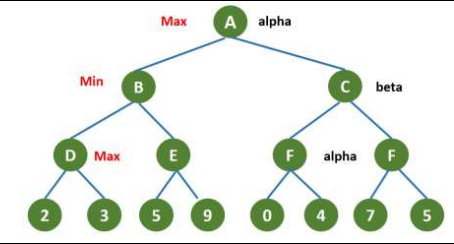

In [ ]:
import math

class Node:
    def __init__(self, value=None):
        self.value = value
        self.children = []
        self.minmax_value = None


def minmax(node, depth, maximizing_player=True):
    if depth == 0 or not node.children:
        return node.value

    if maximizing_player:
        value = -math.inf
        for child in node.children:
            child_value = minmax(child, depth-1, False)
            value = max(value, child_value)
        node.minmax_value = value
        return value
    else:
        value = math.inf
        for child in node.children:
            child_value = minmax(child, depth-1, True)
            value = min(value, child_value)
        node.minmax_value = value
        return value

# Sample tree
root = Node()
root.value = 'A'

n1 = Node('B')
n2 = Node('C')
root.children = [n1, n2]

n3 = Node('D')
n4 = Node('E')
n5 = Node('F')
n6 = Node('G')
n1.children = [n3, n4]
n2.children = [n5, n6]

n7 = Node(2)
n8 = Node(3)
n9 = Node(5)
n10 = Node(9)
n3.children = [n7, n8]
n4.children = [n9, n10]

n11 = Node(0)
n12 = Node(4)
n13 = Node(7)
n14 = Node(5)
n5.children = [n11, n12]
n6.children = [n13, n14]

# Example usage
minmax(root, 3)
print("Minimax values:")
print("A:", root.minmax_value)
print("B:", n1.minmax_value)
print("C:", n2.minmax_value)
print("D:", n3.minmax_value)
print("E:", n4.minmax_value)
print("F:", n5.minmax_value)
print("G:", n6.minmax_value)


Minimax values:
A: 4
B: 3
C: 4
D: 3
E: 9
F: 4
G: 7


# **MiniMax Algorithm - Example**
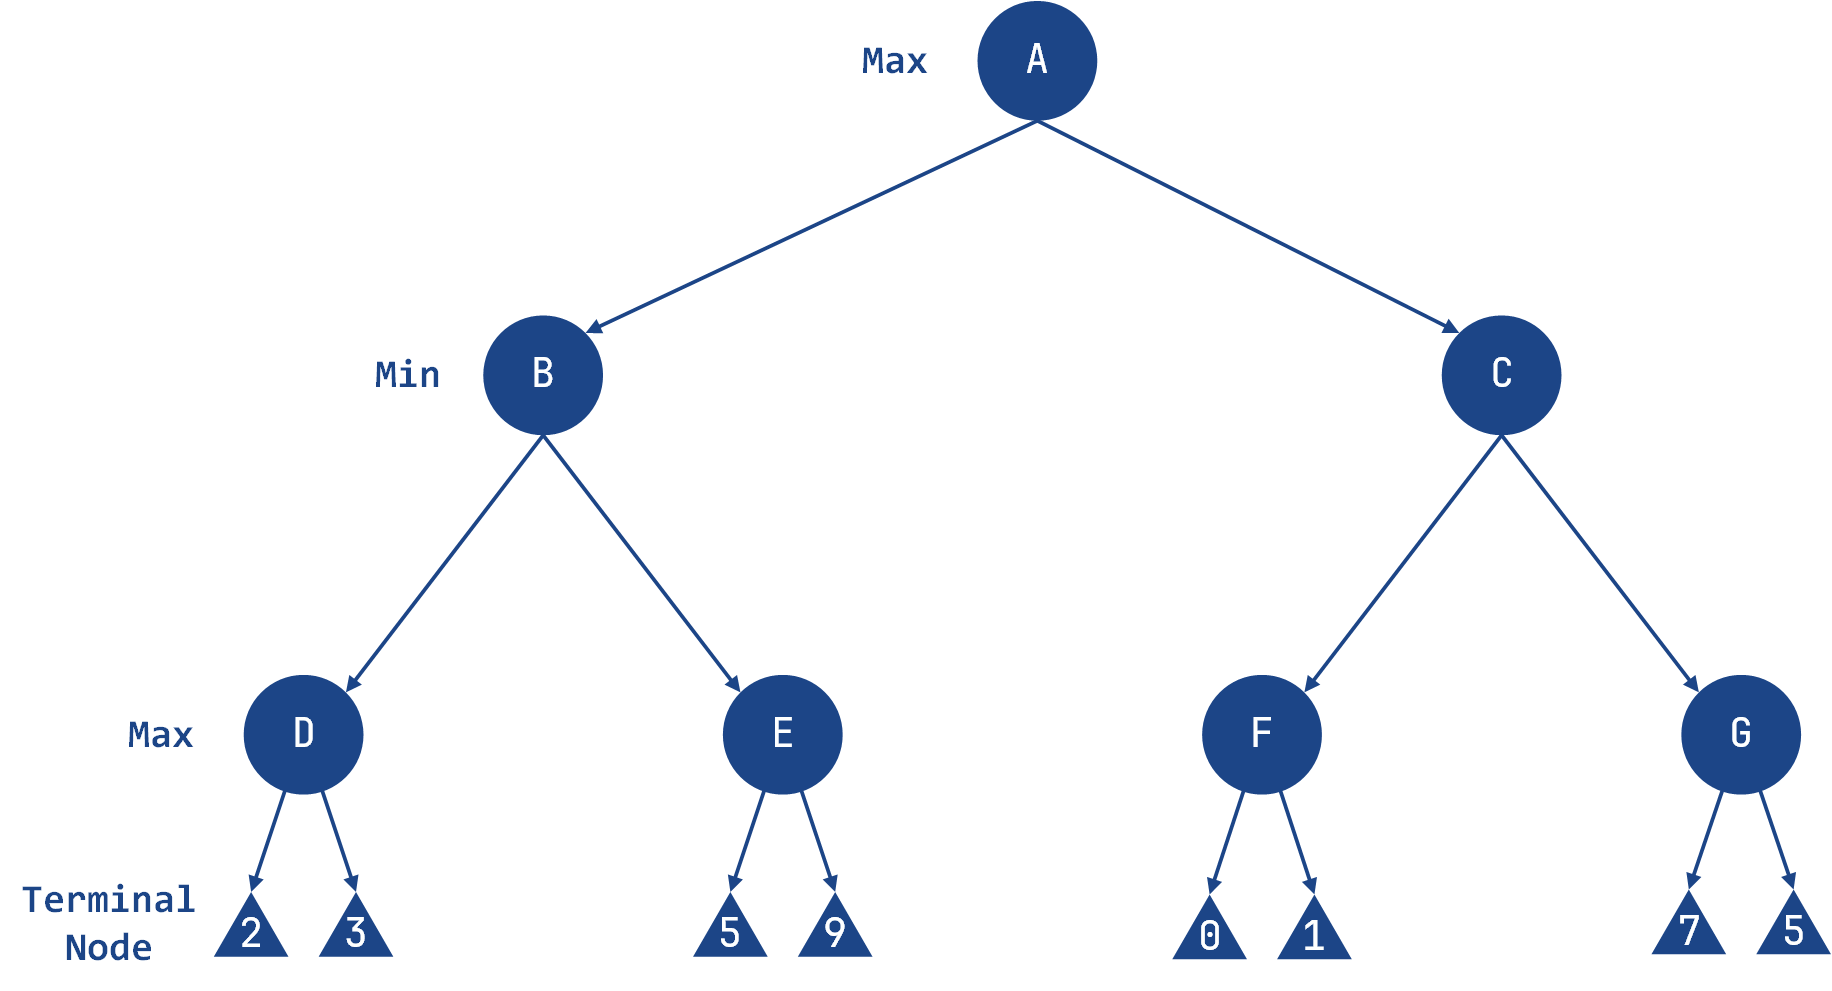

In [ ]:
import math

class Node:
    def __init__(self, value=None):
        self.value = value
        self.children = []
        self.minmax_value = None

In [ ]:
class MinimaxAgent:
    def __init__(self, depth):
        self.depth = depth

    def formulate_goal(self, node):
        # in Minimax, the goal is to compute the minimax value for the root node
        return "Goal reached" if node.minmax_value is not None else "Searching"

    def act(self, node, environment):
        goal_status = self.formulate_goal(node)
        if goal_status == "Goal reached":
            return f"Minimax value for root node: {node.minmax_value}"
        else:
            return environment.compute_minimax(node, self.depth)

In [ ]:
class Environment:
    def __init__(self, tree):
        self.tree = tree
        self.computed_nodes = []

    def get_percept(self, node):
        return node

    def compute_minimax(self, node, depth, maximizing_player=True):
        if depth == 0 or not node.children:
            self.computed_nodes.append(node.value)
            return node.value

        if maximizing_player:
            value = -math.inf
            for child in node.children:
                child_value = self.compute_minimax(child, depth - 1, False)
                value = max(value, child_value)
            node.minmax_value = value
            self.computed_nodes.append(node.value)
            return value
        else:
            value = math.inf
            for child in node.children:
                child_value = self.compute_minimax(child, depth - 1, True)
                value = min(value, child_value)
            node.minmax_value = value
            self.computed_nodes.append(node.value)
            return value

In [ ]:
def run_agent(agent, environment, start_node):
    percept = environment.get_percept(start_node)
    agent.act(percept, environment)

In [ ]:
# sample tree
root = Node('A')
n1 = Node('B')
n2 = Node('C')
root.children = [n1, n2]

n3 = Node('D')
n4 = Node('E')
n5 = Node('F')
n6 = Node('G')
n1.children = [n3, n4]
n2.children = [n5, n6]

n7 = Node(2)
n8 = Node(3)
n9 = Node(5)
n10 = Node(9)
n3.children = [n7, n8]
n4.children = [n9, n10]

n11 = Node(0)
n12 = Node(1)
n13 = Node(7)
n14 = Node(5)
n5.children = [n11, n12]
n6.children = [n13, n14]


# define depth for Minimax
depth = 3

agent = MinimaxAgent(depth)
environment = Environment(root)

run_agent(agent, environment, root)

print("Computed Nodes:", environment.computed_nodes)


print("Minimax values:")
print("A:", root.minmax_value)
print("B:", n1.minmax_value)
print("C:", n2.minmax_value)
print("D:", n3.minmax_value)
print("E:", n4.minmax_value)
print("F:", n5.minmax_value)
print("G:", n6.minmax_value)

Computed Nodes: [2, 3, 'D', 5, 9, 'E', 'B', 0, 1, 'F', 7, 5, 'G', 'C', 'A']
Minimax values:
A: 3
B: 3
C: 1
D: 3
E: 9
F: 1
G: 7


#**Alpha Beta Pruning**

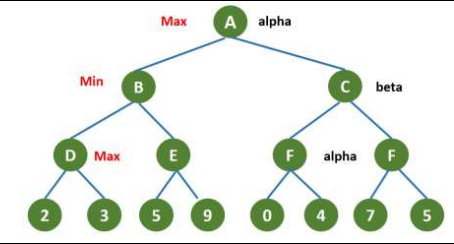

In [7]:
import math

class Node:
    def __init__(self, value=None):
        self.value = value
        self.children = []

def alpha_beta(node, depth, alpha, beta, maximizing_player=True):
    if depth == 0 or not node.children:
        return node.value

    if maximizing_player:
        value = -math.inf
        for child in node.children:
            value = max(value, alpha_beta(child, depth-1, alpha, beta, False))
            alpha = max(alpha, value)
            if beta <= alpha:
                print("Pruned node:", node)
                break
        node.minmax_value = value
        return value
    else:
        value = math.inf
        for child in node.children:
            value = min(value, alpha_beta(child, depth-1, alpha, beta, True))
            beta = min(beta, value)
            if beta < alpha:
                print("Pruned node:", child.value)
                break
        node.minmax_value = value
        return value

# Sample tree
root = Node()
root.value = 'A'

n1 = Node('B')
n2 = Node('C')
root.children = [n1, n2]

n3 = Node('D')
n4 = Node('E')
n5 = Node('F')
n6 = Node('G')
n1.children = [n3, n4]
n2.children = [n5, n6]

n7 = Node(2)
n8 = Node(3)
n9 = Node(5)
n10 = Node(9)
n3.children = [n7, n8]
n4.children = [n9, n10]

n11 = Node(0)
n12 = Node(2)
n13 = Node(7)
n14 = Node(5)
n5.children = [n11, n12]
n6.children = [n13, n14]

# Example usage
alpha_beta(root, 3, -math.inf, math.inf)
print("Minimax values:")
print("A:", root.minmax_value)
print("B:", n1.minmax_value)
print("C:", n2.minmax_value)
print("D:", n3.minmax_value)
print("E:", n4.minmax_value)
print("F:", n5.minmax_value)
# print("G:", n6.minmax_value)


Pruned node: <__main__.Node object at 0x0000017FE7E375C0>
Pruned node: F
Minimax values:
A: 3
B: 3
C: 2
D: 3
E: 5
F: 2


# **MiniMax with Alpha-Beta Pruning Algorithm - Example**
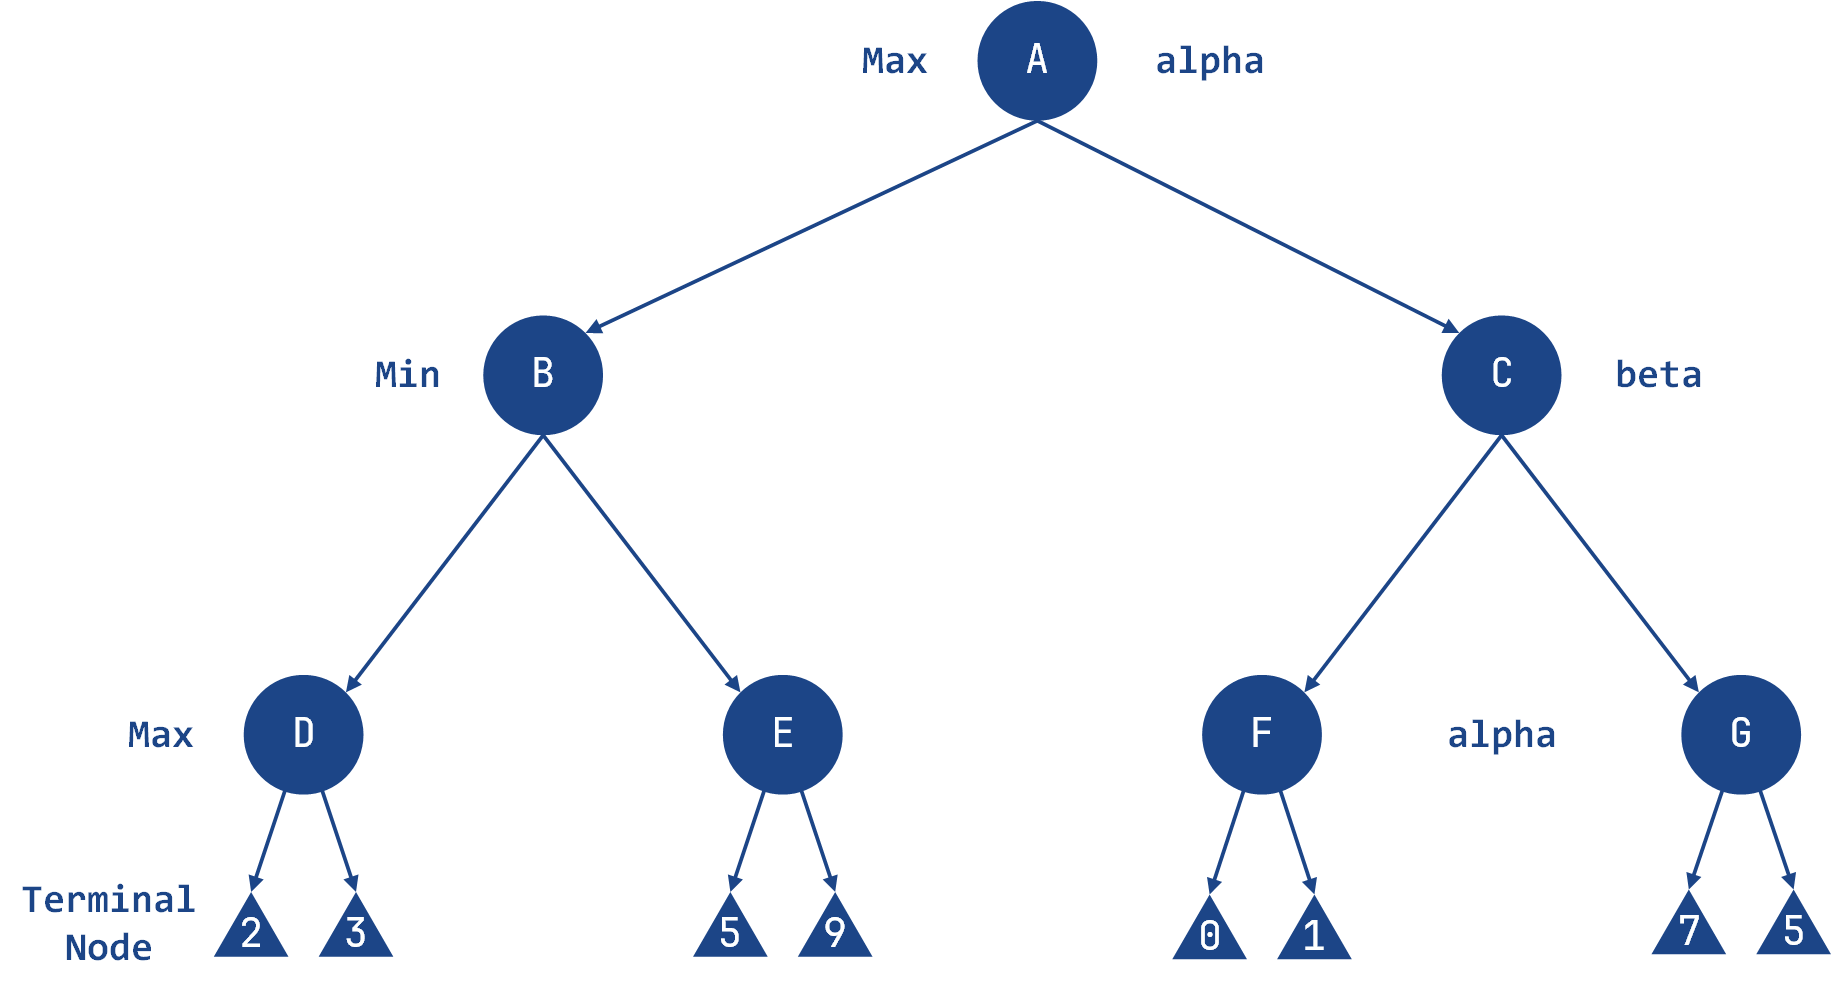

In [ ]:
import math

class Node:
    def __init__(self, value=None):
        self.value = value
        self.children = []
        self.minmax_value = None

In [ ]:
class MinimaxAgent:
    def __init__(self, depth):
        self.depth = depth

    def formulate_goal(self, node):
        return "Goal reached" if node.minmax_value is not None else "Searching"

    def act(self, node, environment):
        goal_status = self.formulate_goal(node)
        if goal_status == "Goal reached":
            return f"Minimax value for root node: {node.minmax_value}"
        else:
            return environment.alpha_beta_search(node, self.depth, -math.inf, math.inf, True)

In [ ]:
class Environment:
    def __init__(self, tree):
        self.tree = tree
        self.computed_nodes = []

    def get_percept(self, node):
        return node

    def alpha_beta_search(self, node, depth, alpha, beta, maximizing_player=True):
        self.computed_nodes.append(node.value)
        if depth == 0 or not node.children:
            return node.value

        if maximizing_player:
            value = -math.inf
            for child in node.children:
                value = max(value, self.alpha_beta_search(child, depth - 1, alpha, beta, False))
                alpha = max(alpha, value)
                if beta <= alpha:
                    print("Pruned node:", child.value)
                    break
            node.minmax_value = value
            return value
        else:
            value = math.inf
            for child in node.children:
                value = min(value, self.alpha_beta_search(child, depth - 1, alpha, beta, True))
                beta = min(beta, value)
                if beta <= alpha:
                    print("Pruned node:", child.value)
                    break
            node.minmax_value = value
            return value

In [ ]:
def run_agent(agent, environment, start_node):
    percept = environment.get_percept(start_node)
    agent.act(percept, environment)

In [ ]:
# constructing the tree
root = Node('A')
n1 = Node('B')
n2 = Node('C')
root.children = [n1, n2]

n3 = Node('D')
n4 = Node('E')
n5 = Node('F')
n6 = Node('G')
n1.children = [n3, n4]
n2.children = [n5, n6]

n7 = Node(2)
n8 = Node(3)
n9 = Node(5)
n10 = Node(9)
n3.children = [n7, n8]
n4.children = [n9, n10]

n11 = Node(0)
n12 = Node(1)
n13 = Node(7)
n14 = Node(5)
n5.children = [n11, n12]
n6.children = [n13, n14]

# define depth for Alpha-Beta pruning
depth = 3

agent = MinimaxAgent(depth)
environment = Environment(root)

run_agent(agent, environment, root)

print("Computed Nodes:", environment.computed_nodes)
print("Minimax values:")
print(f"A: {root.minmax_value}")
print(f"B: {n1.minmax_value}")
print(f"C: {n2.minmax_value}")
print(f"D: {n3.minmax_value}")
print(f"E: {n4.minmax_value}")
print(f"F: {n5.minmax_value}")
print(f"G: {n6.minmax_value}")

Pruned node: 5
Pruned node: F
Computed Nodes: ['A', 'B', 'D', 2, 3, 'E', 5, 'C', 'F', 0, 1]
Minimax values:
A: 3
B: 3
C: 1
D: 3
E: 5
F: 1
G: None
